# Fitting Example (NLSF & MLE) in CPU and GPU - Mono-exponential FLI data processing

This example fits a simulated, mono-exponential fluorescence lifetime image (FLI) pixel by pixel with two estimators and compares them against the known ground truth:

- **Non-linear least squares (NLSF)**: minimizes the weighted sum of squared residuals between the IRF-convolved model and the decay.
- **Maximum likelihood estimation (MLE)**: maximizes the Poisson log-likelihood of the photon counts directly.

Each estimator is run on the CPU (pixel by pixel, in parallel) and on the GPU (all pixels as one batch).

This example walks through:
- Simulating a whole FLI image with known lifetimes (as in the "Whole Image Simulation" example)
- Fitting the whole image with NLSF and with MLE on the CPU
- Fitting the same image with NLSF and with MLE on the GPU
- Comparing the CPU and GPU lifetime maps, their distributions, accuracy and fit quality with the ground truth
- Comparing CPU and GPU estimates pixel by pixel, and the four fits at a single pixel

<small>Author - Vikas</small>

In [1]:
import sys

import numpy as np

sys.path.insert(0, "ex_helper")  # local helper for synthetic image generation

from sim_general_image import LettersShape, ROIMaskGenerator

from pyfli.analysis.utils import plot_pixel_diagnostic, random_true_pixel
from pyfli.analyticalWorkflow import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.data_text import MessageDisplay
from pyfli.data_vnp import ColorProcessor, DataViewer, Plotter
from pyfli.io import DataOperations
from pyfli.simulator import FLIModelImageGenerator
from pyfli.solver import (
    BaseFLIFitter,
    BinnedFLIFitter,
    FittingComparator,
    FLICPUProcessor,
    MLEFLIFitter,
)

## Generating a test image

A test image is simulated to compare the ground truth against the estimated values. In this example, a 128 x 512 image is generated with the letters "F", "L", "I", "M". Each letter is assigned a different intensity value (grayscale bit size) and a different lifetime: 0.7 ± 0.05 ns, 0.8 ± 0.05 ns, 0.9 ± 0.05 ns, and 1.0 ± 0.05 ns, respectively.

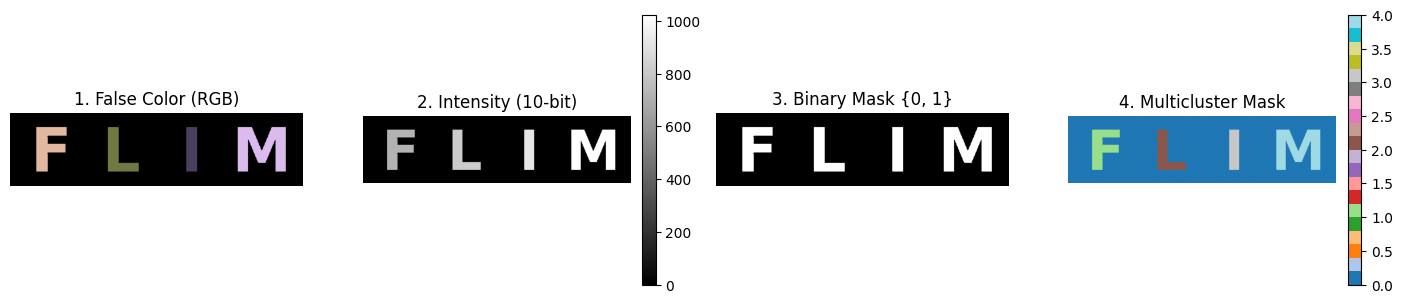

In [2]:
h, w = 128, 512
generator = ROIMaskGenerator((h, w), top=10, bottom=10, left=10, right=10)
FLIM_letters = LettersShape(letters=("F", "L", "I", "M"), gap=0.15)

custom_intensities = [0.7, 0.8, 0.9, 1.0]
# Preview the generated image
_ = generator.plot_preview(
    FLIM_letters,
    bit_depth=10,
    intensities=custom_intensities,
    show=True,
)

## Loading the IRF

The instrument response function (IRF) is convolved with the decay model during both simulation and fitting. Its number of time gates also sets the gate width and the laser/acquisition frequencies used by the fitters.

In [3]:
# Path to the local IRF file
IRF_PATH = "<select file/folder path>"

In [4]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()

gate_delay = 12.5 / irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(
    laser_period=12.5, gate_delay=gate_delay, num_gate=num_gates
).freq_computation()

INFO:pyfli:Initiating IRF load from: <select file/folder path>


## Simulation configuration

`MODEL_TYPE` selects the decay model for both the simulation and the fits. Setting `mono_fraction` to 1.0 forces every simulated pixel to be mono-exponential.

In [5]:
MODEL_TYPE = "mono-exponential"

# Your constant, default configuration
BASE_CONFIG = {
    # Modular Noise
    "jitter": False,  # offset artifact (due to jitter)
    "dcr_on": True,  # Dark Count Rate (thermal background)
    "poisson": False,  # Shot noise — Large detector only
    "qe_on": True,  # Quantum efficiency scaling
    "read_noise_on": False,  # Gaussian read noise — Large detector only
    # Sensor
    "sensor_type": "discrete",  # "continuous" | "discrete"
    "bit": 12,
    "dcr": 0.08,  # Mean dark counts per bin
    "laser_feq": freq[1],  # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on": True,  # Round photon counts to integers — Macro_sim only
    "clip_on": True,  # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count
    # Fluorescence Physics (FLI / FRET)
    "tau2": (1, 1),  # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist": "beta",  # if dist "beta" or "normal" (default)
    "efficiency": (1, 1),  # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction": (1, 1),  # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count": (2, 5),  # Peak intensity ~ Beta(2, 5) × max_adc - large detectors
    "mono_fraction": 1.0,  # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles": (1_500_000, 2_000_000),  # Accumulation cycles — for photon counter
}

Different ROIs (letter areas, in this case) are assigned different lifetimes.

In [6]:
def get_config(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG.copy()
    config.update(kwargs)
    return config


ROI0 = {}
ROI1 = get_config(
    tau2_beta_range=(0.05, 0.5),
)
ROI2 = get_config(
    tau2_beta_range=(0.05, 0.7),
)
ROI3 = get_config(
    tau2_beta_range=(0.05, 0.9),
)
ROI4 = get_config(
    tau2_beta_range=(0.05, 1.1),
)

In [7]:
img_intensity = generator.generate_intensity_image(
    FLIM_letters, intensities=custom_intensities
)
img_cluster = generator.generate_cluster_mask(FLIM_letters)
b_bool_mask = generator.generate_binary_mask(FLIM_letters)

simulated_img = FLIModelImageGenerator(
    irf_data=irf_data[120, 40, :],
    intensity_image=img_intensity,
    roi_mask=img_cluster,
    roi_params=[ROI0, ROI1, ROI2, ROI3, ROI4],
    method="PHOTON_COUNTER",
    verbose=True,
    bool_mask=b_bool_mask,
)

gt_data = simulated_img.generate_image()

INFO:pyfli:Generating PHOTON_COUNTER FLI Image [128x512x256]...


### Ground-truth maps

The simulator returns the parameter maps used to generate the data. These are the reference values for the fits below.

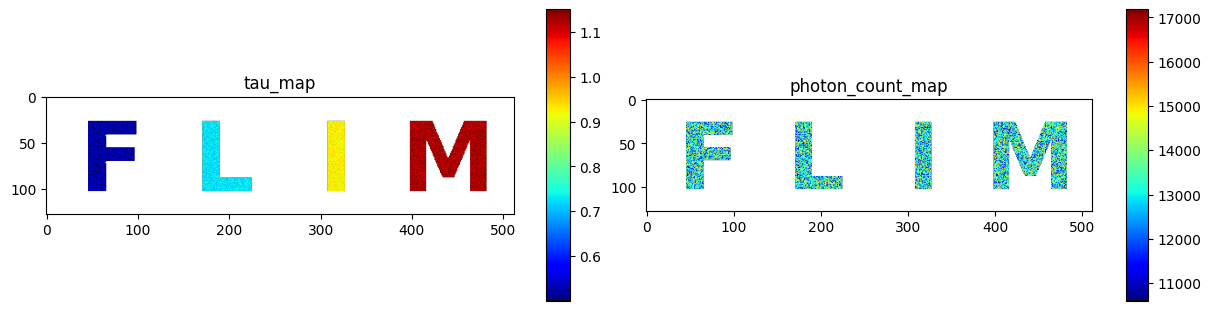

In [8]:
gt_maps = gt_data["results"]["maps"]
jet_m = ColorProcessor().lowest_zero("jet")

_ = DataViewer().display_data(
    [gt_maps["tau_map"], gt_maps["photon_count_map"]],
    structure=(1, 2),
    coord=None,
    data_names=["tau_map", "photon_count_map"],
    cmaps=[jet_m] * 2,
    v_ranges=None,
    figsize=(12, 3),
    normalize=False,
    yscale="linear",
)

Check the decay, IRF, and fit at a randomly selected pixel.

the non-zero pixel selected for probing is (40, 65)


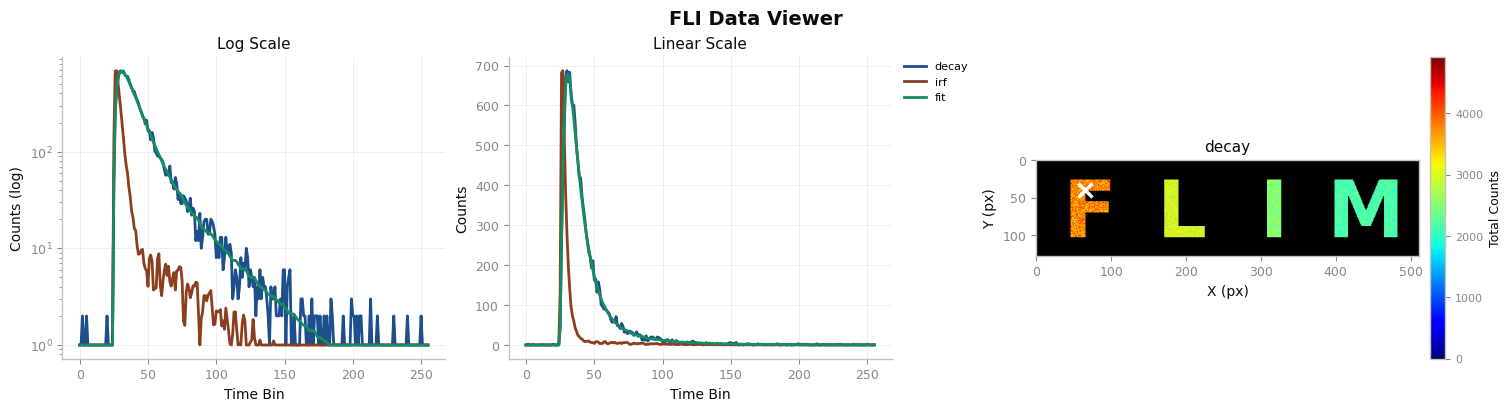

INFO:pyfli:
  Pixel (40, 65)
  ─────────────────────
  A         13427.7539
  α         —
  τ₁        0.5267
  τ₂        —
  R²        —
  Red.χ²    —
  Raw.χ²    —
  Pearson   —
  v-shift   0.0000
  h-shift   —
  ─────────────────────



In [9]:
_decay = gt_data["raw_data"]["decay"]
_irf = gt_data["raw_data"]["irf"]
x, y = random_true_pixel(b_bool_mask)
TRs = gt_data["results"]["TR_maps"]
print(f"the non-zero pixel selected for probing is ({x}, {y})")
irf_norm = Normalization(_irf).norm_scale(_decay)
DataViewer().plot_fli_px(
    data_list=[_decay, irf_norm, TRs["fit_map"], TRs["residual_map"]],
    pixel=(x, y),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m,
)
_ = MessageDisplay().get_pixel_summary(data_maps=gt_maps, px=(x, y))

## Whole-image fitting

Each pixel is fitted independently and in parallel on the CPU:

- `FLICPUProcessor(freq, fitter_class)` spreads the per-pixel fits over `n_jobs` worker processes. The fitter class sets the estimator family.
- `BinnedFLIFitter(..., bin_radius=0)` is the image-level entry point. A `bin_radius` of 0 fits every pixel as-is, and a larger radius sums each pixel with its neighbours first to raise the photon count.
- `max_iter` caps the optimizer's function evaluations per pixel.

The GPU counterpart, `FLIGPUProcessor`, is used in the next section.

### NLSF

In [11]:
MAX_ITER = 1000
N_JOBS = 7

nlsf_fitter = BinnedFLIFitter(FLICPUProcessor(freq, BaseFLIFitter), bin_radius=0)
results_nlsf = nlsf_fitter.fit(
    b_img=_decay,
    b_irf=_irf,
    estimator="least_squares",
    model_type=MODEL_TYPE,
    n_jobs=N_JOBS,
    data_name="simulated_nlsf",
    max_iter=MAX_ITER,
)

INFO:pyfli:Engine: CPU Parallel Processor (via FLICPUProcessor)
Fitting Pixels (least_squares): 100%|██████████| 10241/10241 [00:47<00:00, 214.35px/s]


### MLE

The same pipeline is run with `MLEFLIFitter` and the `"poisson"` estimator. MLE takes longer per pixel than NLSF.

In [12]:
mle_fitter = BinnedFLIFitter(FLICPUProcessor(freq, MLEFLIFitter), bin_radius=0)
results_mle = mle_fitter.fit(
    b_img=_decay,
    b_irf=_irf,
    estimator="poisson",
    model_type=MODEL_TYPE,
    n_jobs=N_JOBS,
    data_name="simulated_mle",
    max_iter=MAX_ITER,
)

INFO:pyfli:Engine: CPU Parallel Processor (via FLICPUProcessor)
Fitting Pixels (poisson): 100%|██████████| 10241/10241 [01:19<00:00, 128.66px/s]


## GPU-based estimation

`FLIGPUProcessor` fits **all pixels at once** as one batched problem with the Adam optimizer on the GPU (CUDA when available, otherwise the CPU). It uses the same forward model as the CPU fitters -- the gate-integrated decay with onset `h_shift`, convolved with the IRF -- and the same estimators:

- `estimator="least_squares"` -- NLSF with IRLS weighting (squared residuals divided by the current model value), the batched counterpart of the CPU default;
- `estimator="poisson"` -- Poisson MLE (deviance).

It plugs into the same `BinnedFLIFitter`, so the calls below differ from the CPU ones only in the processor. For the GPU, `max_iter` is the number of Adam steps shared by all pixels (optimization stops early once the loss stops improving).

In [17]:
import time

import pandas as pd
import torch

from pyfli.solver import FLIGPUProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"FLIGPUProcessor device: {DEVICE}")

FLIGPUProcessor device: cuda


### GPU NLSF

In [18]:
start = time.time()
gpu_nlsf_fitter = BinnedFLIFitter(FLIGPUProcessor(freq, device=DEVICE), bin_radius=0)
results_gpu_nlsf = gpu_nlsf_fitter.fit(
    b_img=_decay,
    b_irf=_irf,
    estimator="least_squares",
    model_type=MODEL_TYPE,
    data_name="simulated_gpu_nlsf",
    max_iter=MAX_ITER,
)
time_gpu_nlsf = time.time() - start
print(f"GPU NLSF: {time_gpu_nlsf:.1f} s")

INFO:pyfli:Using Device: cuda
INFO:pyfli:Engine: GPU Vectorized Processor (via FLIGPUProcessor)
INFO:pyfli:--- GPU NLSF Processing (10241 pixels) ---
Optimizing (NLSF): 100%|██████████| 1000/1000 [00:29<00:00, 33.99it/s]
INFO:pyfli:Fit Finished in 32.59s


GPU NLSF: 32.8 s


### GPU MLE

In [19]:
start = time.time()
gpu_mle_fitter = BinnedFLIFitter(FLIGPUProcessor(freq, device=DEVICE), bin_radius=0)
results_gpu_mle = gpu_mle_fitter.fit(
    b_img=_decay,
    b_irf=_irf,
    estimator="poisson",
    model_type=MODEL_TYPE,
    data_name="simulated_gpu_mle",
    max_iter=MAX_ITER,
)
time_gpu_mle = time.time() - start
print(f"GPU MLE: {time_gpu_mle:.1f} s")

INFO:pyfli:Using Device: cuda
INFO:pyfli:Engine: GPU Vectorized Processor (via FLIGPUProcessor)
INFO:pyfli:--- GPU MLE Processing (10241 pixels) ---
Optimizing (MLE): 100%|██████████| 1000/1000 [00:31<00:00, 31.42it/s]
INFO:pyfli:Fit Finished in 32.43s


GPU MLE: 32.6 s


## Comparing CPU and GPU estimates

The four estimates -- NLSF and MLE, each on the CPU and on the GPU -- against the ground truth.

### Lifetime maps

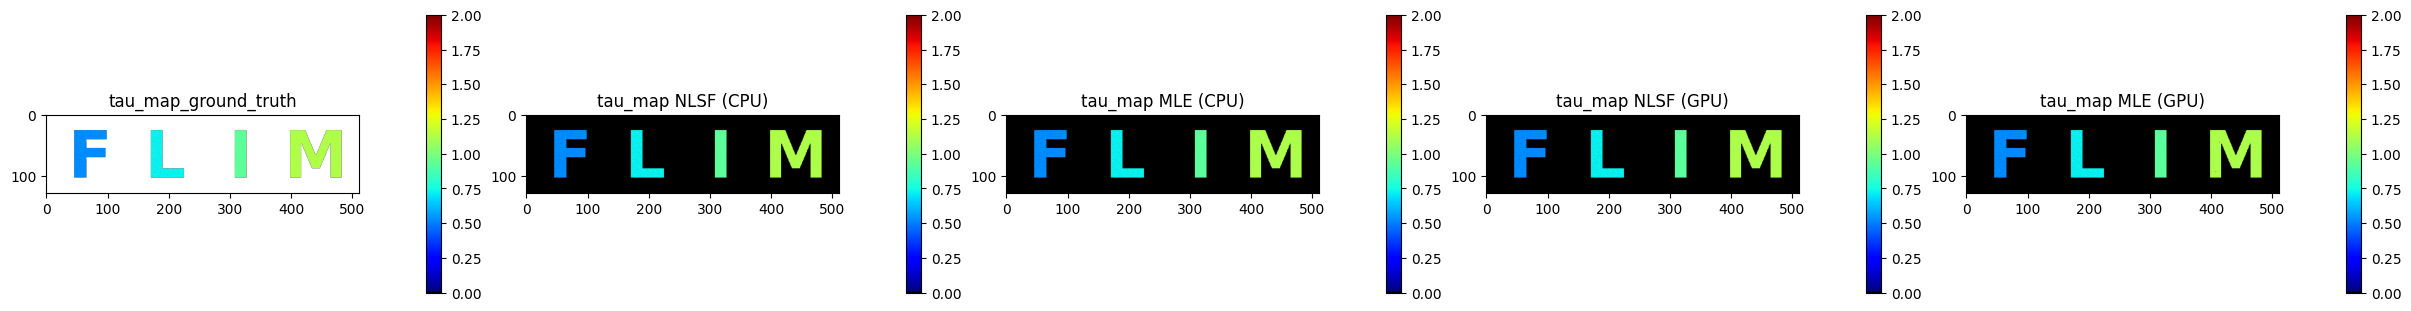

In [20]:
experiments_all = {
    "NLSF (CPU)": results_nlsf,
    "MLE (CPU)": results_mle,
    "NLSF (GPU)": results_gpu_nlsf,
    "MLE (GPU)": results_gpu_mle,
}
maps_all = [res["results"]["maps"] for res in experiments_all.values()]
fitsets_all = [res["results"]["TR_maps"] for res in experiments_all.values()]

_ = DataViewer().display_data(
    [gt_maps["tau_map"]] + [maps["tau_map"] for maps in maps_all],
    structure=(1, len(maps_all) + 1),
    coord=None,
    data_names=["tau_map_ground_truth"] + [f"tau_map {name}" for name in experiments_all],
    cmaps=[jet_m] * (len(maps_all) + 1),
    v_ranges=[(0, 2)] * (len(maps_all) + 1),
    figsize=(24, 3),
    normalize=False,
    yscale="linear",
)

### Lifetime distributions

`Plotter` compares the lifetime values of the letter pixels across the sources. The `operations` dict is applied to every source: it keeps only pixels inside the mask, drops failed fits (NaN or zero) and discards values outside the threshold range. A list of dicts, one per source, can be passed instead to filter each source differently. `graph_type` can also be `"box"`, `"swarm"`, `"overlay"`, `"raincloud"` or `"kde"`, and `test_type="paired"` or `"welch"` adds significance tests between the sources.

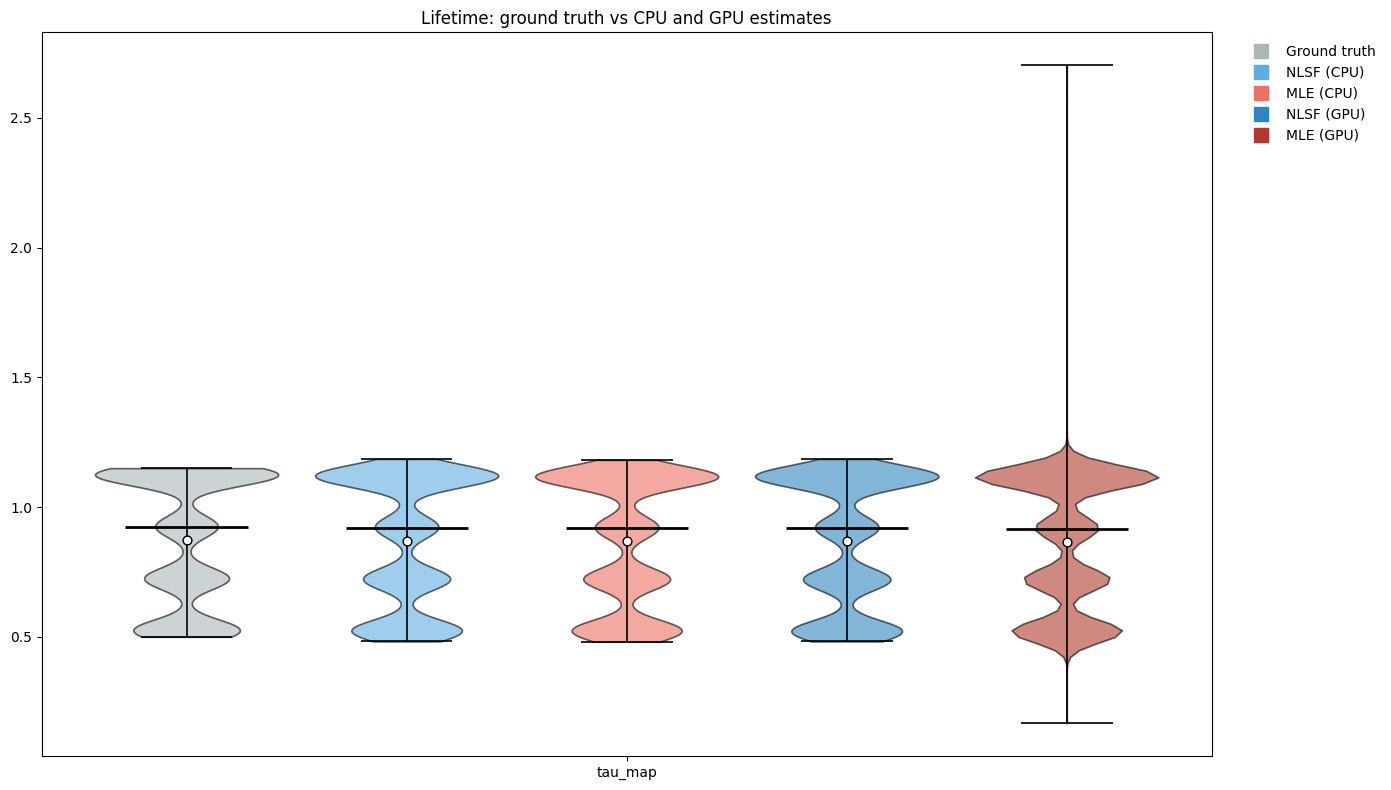

In [21]:
plotter_ops = {
    "mask": b_bool_mask.ravel(),
    "remove_nan": True,
    "remove_zero": True,
    "threshold": (0, 7),
}

painter_all = Plotter(
    gt_maps,
    *maps_all,
    values=["tau_map"],
    style_config=["#AAB7B8", "#5DADE2", "#EC7063", "#2E86C1", "#B03A2E"],
    source_names=["Ground truth"] + list(experiments_all),
    operations=plotter_ops,
)
fig = painter_all.make_plot(
    title="Lifetime: ground truth vs CPU and GPU estimates",
    graph_type="violin",
    point_type="strip",
    show_mean=True,
    show_median=True,
    show_significance=True,
    test_type="none",
    correction=False,
)

### Accuracy and fit quality

Per method, over the letter pixels: the median relative bias and the spread of `tau / tau_true - 1`, the median reduced chi-square (Poisson deviance over its expectation, about 1 for a good fit), and the number of pixels without a valid lifetime. The CPU fitting times are shown by the progress bars of the CPU cells above.

In [25]:
letters = b_bool_mask.astype(bool)
tau_true = gt_maps["tau_map"][letters]
fit_times = {"NLSF (GPU)": time_gpu_nlsf, "MLE (GPU)": time_gpu_mle}

rows = []
for name, maps in zip(experiments_all, maps_all):
    tau = maps["tau_map"][letters]
    valid = np.isfinite(tau) & (tau > 0)
    rel = tau[valid] / tau_true[valid] - 1.0
    rows.append(
        {
            "method": name,
            "median bias (%)": 100 * np.median(rel),
            "spread (std, %)": 100 * np.std(rel),
            "median reduced chi2": np.nanmedian(maps["reduced_chi2_map"][letters][valid]),
        }
    )
pd.DataFrame(rows).set_index("method").round(3)

,median bias (%),"spread (std, %)",median reduced chi2
method,,,
NLSF (CPU),-0.298,1.209,1.032
MLE (CPU),-0.480,1.200,1.012
NLSF (GPU),-0.557,1.203,1.061
MLE (GPU),-0.694,2.405,1.048


### CPU vs GPU, pixel by pixel

Each point is one letter pixel: the GPU lifetime against the CPU lifetime for the same estimator. Points on the diagonal mean both processors reached the same solution.

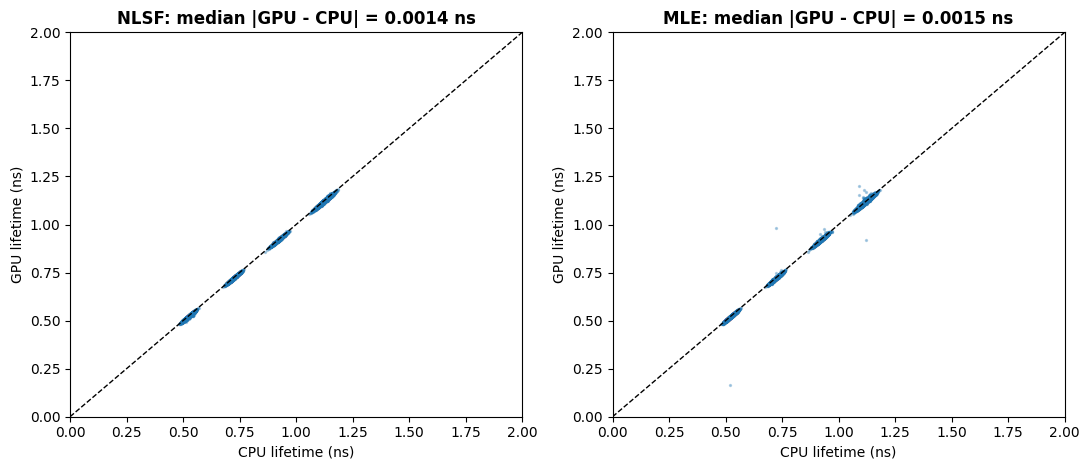

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, est in zip(axes, ["NLSF", "MLE"]):
    tau_cpu = experiments_all[f"{est} (CPU)"]["results"]["maps"]["tau_map"][letters]
    tau_gpu = experiments_all[f"{est} (GPU)"]["results"]["maps"]["tau_map"][letters]
    ok = np.isfinite(tau_cpu) & np.isfinite(tau_gpu) & (tau_cpu > 0) & (tau_gpu > 0)
    ax.scatter(tau_cpu[ok], tau_gpu[ok], s=2, alpha=0.3)
    lim = (0, 2)
    ax.plot(lim, lim, "k--", linewidth=1)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    diff = np.abs(tau_gpu[ok] - tau_cpu[ok])
    ax.set_title(f"{est}: median |GPU - CPU| = {np.median(diff):.4f} ns", fontweight="bold")
    ax.set_xlabel("CPU lifetime (ns)")
    ax.set_ylabel("GPU lifetime (ns)")
fig.tight_layout()
plt.show()

### Fits at a single pixel

The pixel probed in the ground-truth check above, now with all four fitted curves.

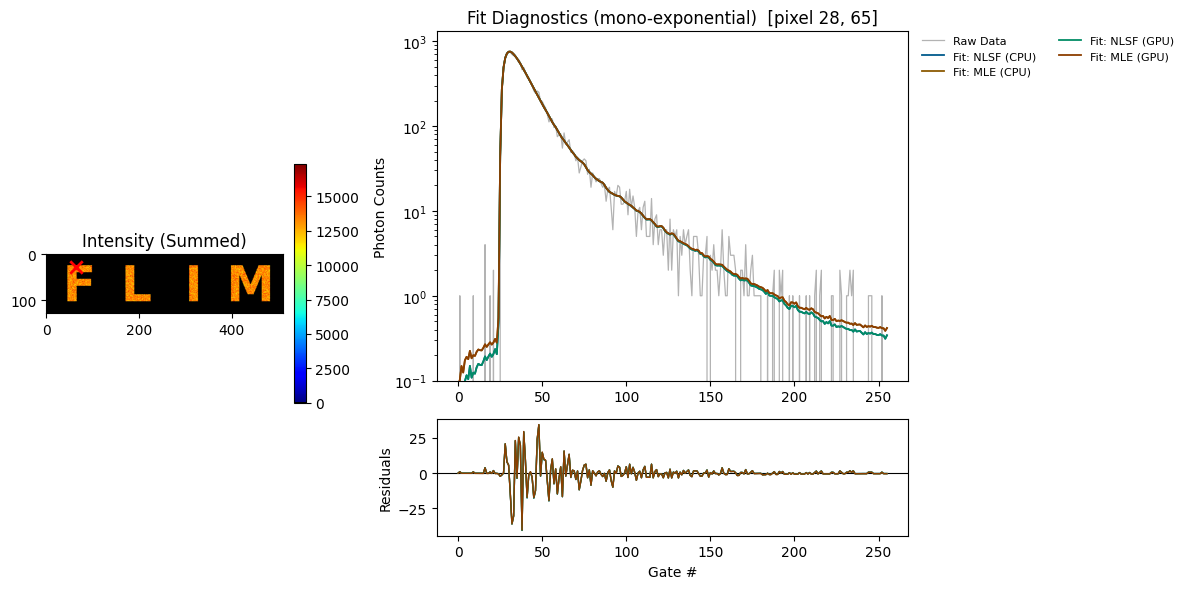

In [24]:
_ = plot_pixel_diagnostic(
    _decay,
    fitsets_all,
    list(experiments_all),
    mask=b_bool_mask,
    pixel=(x, y),
    t=None,
    yscale="log",
    raw_style="line",
    model_type=MODEL_TYPE,
)